<a href="https://colab.research.google.com/github/Ryuta-Y/pytorch-practice/blob/main/pytorch_practice_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt

training_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.2MB/s]


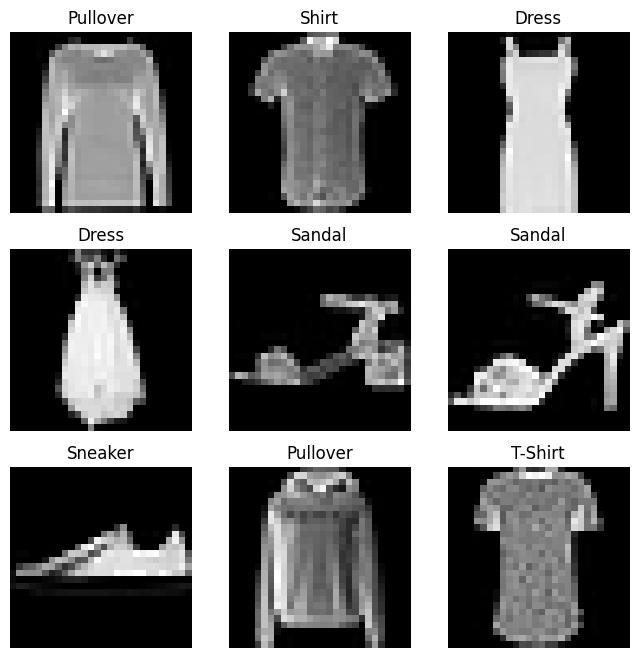

In [2]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  img, label = training_data[sample_idx]
  figure.add_subplot(rows,cols,i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(),cmap="gray")
plt.show()

In [3]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        sample = {"image": image, "label": label}
        return sample

In [4]:
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

In [5]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [6]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print('Using {} device'.format(device))

Using cuda device


In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [8]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
    (5): ReLU()
  )
)


In [14]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([4], device='cuda:0')


In [17]:
input_image = torch.rand(3,28,28)
print(input_image.size())

flatten = nn.Flatten()
flat_image = flatten(input_image)

layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
hidden2= layer1(flat_image)
print(hidden1.size())

print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

print(f"Before GeLU: {hidden2}\n\n")
hidden1 = nn.GELU()(hidden2)
print(f"After GeLU: {hidden2}")

torch.Size([3, 28, 28])
torch.Size([3, 20])
Before ReLU: tensor([[-0.1118,  0.0798, -0.0395,  0.2445,  0.0053,  0.1903, -0.0647, -0.0809,
          0.5758, -0.2639, -0.1988, -0.3233,  0.2219, -0.2756, -0.4086, -0.1002,
          0.0743, -0.2932, -0.3779,  0.1907],
        [ 0.0302, -0.0345,  0.0257,  0.3875,  0.0563,  0.3801, -0.1236, -0.0143,
          0.3019, -0.0890, -0.2643, -0.7971, -0.0340, -0.1278,  0.0272,  0.3898,
         -0.1704,  0.0984,  0.2954, -0.2589],
        [-0.3686,  0.0706,  0.0921,  0.6042,  0.0305,  0.1888, -0.0230, -0.0899,
          0.6609, -0.0465, -0.0755, -0.3374,  0.1031, -0.2206, -0.5464, -0.0981,
         -0.0985, -0.2617, -0.2377,  0.1143]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0798, 0.0000, 0.2445, 0.0053, 0.1903, 0.0000, 0.0000, 0.5758,
         0.0000, 0.0000, 0.0000, 0.2219, 0.0000, 0.0000, 0.0000, 0.0743, 0.0000,
         0.0000, 0.1907],
        [0.0302, 0.0000, 0.0257, 0.3875, 0.0563, 0.3801, 0.0000, 0.0000, 0.3019,
         

In [36]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.2682, 0.3313, 0.0744],
        [0.2682, 0.3313, 0.0744],
        [0.2682, 0.3313, 0.0744],
        [0.2682, 0.3313, 0.0744],
        [0.2682, 0.3313, 0.0744]])
tensor([0.2682, 0.3313, 0.0744])


In [42]:
inp = torch.eye(5, requires_grad=True)
out = (inp+1).pow(2)
out.backward(torch.ones_like(inp), retain_graph=True)
print("First call\n", inp.grad)
out.backward(torch.ones_like(inp), retain_graph=True)
print("\nSecond call\n", inp.grad)
out.backward(torch.ones_like(inp), retain_graph=True)
print("\nThird call\n", inp.grad)
inp.grad.zero_()
out.backward(torch.ones_like(inp), retain_graph=True)
print("\nCall after zeroing gradients\n", inp.grad)

First call
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.],
        [2., 2., 2., 2., 4.]])

Second call
 tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.],
        [4., 4., 4., 4., 8.]])

Third call
 tensor([[12.,  6.,  6.,  6.,  6.],
        [ 6., 12.,  6.,  6.,  6.],
        [ 6.,  6., 12.,  6.,  6.],
        [ 6.,  6.,  6., 12.,  6.],
        [ 6.,  6.,  6.,  6., 12.]])

Call after zeroing gradients
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.],
        [2., 2., 2., 2., 4.]])
